<h3> Libraries </h3>

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

<h3> Data Reading </h3>

In [71]:
df = pd.read_csv("../data/raw/survey_responses.csv")
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [72]:
df.head()

,Timestamp,What is your age?,What is your gender?,Occupation,Device Type,Rate your weekly work productivity score on a scale of 0-10.,"To the nearest half hour, what is your average daily screen time during the weekends?","To the nearest half hour, what is your average daily screen time?","To the nearest half hour, how much sleep do you get a night?","To the nearest half hour, on average, how much time do you spend on social media a day?",What is your stress level on a scale of 0 -10?,"How many cups of caffeinated beverages (coffee, energy drinks, etc.) do you drink per day?"
0,2026/02/24 5:26:16 PM PST,22,Male,Student,iOS,6,4 hours,4 hours,7 hours,1.5 hours,7,3
1,2026/02/24 5:27:12 PM PST,23,Female,Student,iOS,9,2.5 hours,2 hours,7 hours,0.5 hours,2,0
2,2026/02/24 5:28:57 PM PST,23,Female,Student;Professional,iOS,6,6 hours,4 hours,7.5 hours,3 hours,4,3
3,2026/02/24 5:29:19 PM PST,23,Male,Student,iOS,6,4.5 hours,3 hours,8 hours,2 hours,5,1
4,2026/02/25 2:44:22 PM PST,24,Female,Student,iOS,10,9 hours,7 hours,6.5 hours,5 hours,7,0


In [73]:
df.shape

(61, 12)

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 12 columns):
 #   Column                                                                                       Non-Null Count  Dtype 
---  ------                                                                                       --------------  ----- 
 0   Timestamp                                                                                    61 non-null     object
 1   What is your age?                                                                            61 non-null     int64 
 2   What is your gender?                                                                         61 non-null     object
 3   Occupation                                                                                   61 non-null     object
 4   Device Type                                                                                  61 non-null     object
 5   Rate your weekly work productivity score on a

In [75]:
df.columns

Index(['Timestamp', 'What is your age?', 'What is your gender?', 'Occupation',
       'Device Type',
       'Rate your weekly work productivity score on a scale of 0-10. ',
       'To the nearest half hour, what is your average daily screen time during the weekends?',
       'To the nearest half hour, what is your average daily screen time?',
       'To the nearest half hour, how much sleep do you get a night?',
       'To the nearest half hour, on average, how much time do you spend on social media a day?',
       'What is your stress level on a scale of 0 -10? ',
       'How many cups of caffeinated beverages (coffee, energy drinks, etc.) do you drink per day? '],
      dtype='object')

In [76]:
df = df.rename(columns={
    "What is your age?": "Age",
    "What is your gender?": "Gender",
    "Occupation": "Occupation",
    "Device Type": "Device_Type",
    "Rate your weekly work productivity score on a scale of 0-10. ": "Work_Productivity_Score",
    "To the nearest half hour, what is your average daily screen time during the weekends?": "Weekend_Screen_Time_Hours",
    "To the nearest half hour, what is your average daily screen time?": "Daily_Phone_Hours",
    "To the nearest half hour, how much sleep do you get a night?": "Sleep_Hours",
    "To the nearest half hour, on average, how much time do you spend on social media a day?": "Social_Media_Hours",
    "What is your stress level on a scale of 0 -10? ": "Stress_Level",
    "How many cups of caffeinated beverages (coffee, energy drinks, etc.) do you drink per day? ": "Caffeine_Intake_Cups"
})

In [77]:
df.describe()

,Age,Work_Productivity_Score,Stress_Level,Caffeine_Intake_Cups
count,61.000000,61.000000,61.000000,61.000000
mean,25.016393,6.672131,6.426230,1.606557
std,4.818339,1.841388,2.283703,1.800728
min,18.000000,1.000000,1.000000,0.000000
25%,22.000000,6.000000,5.000000,0.000000
50%,23.000000,6.000000,7.000000,1.000000
75%,28.000000,8.000000,8.000000,2.000000
max,45.000000,10.000000,10.000000,10.000000


In [78]:
time_cols = [
    "Weekend_Screen_Time_Hours",
    "Daily_Phone_Hours",
    "Sleep_Hours",
    "Social_Media_Hours"
]

for col in time_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.extract(r'(\d+\.?\d*)')[0]
        .astype(float)
    )

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Timestamp                  61 non-null     object 
 1   Age                        61 non-null     int64  
 2   Gender                     61 non-null     object 
 3   Occupation                 61 non-null     object 
 4   Device_Type                61 non-null     object 
 5   Work_Productivity_Score    61 non-null     int64  
 6   Weekend_Screen_Time_Hours  61 non-null     float64
 7   Daily_Phone_Hours          61 non-null     float64
 8   Sleep_Hours                61 non-null     float64
 9   Social_Media_Hours         61 non-null     float64
 10  Stress_Level               61 non-null     int64  
 11  Caffeine_Intake_Cups       61 non-null     int64  
dtypes: float64(4), int64(4), object(4)
memory usage: 5.8+ KB


<h3> Target Col </h3> 

In [80]:
target_col = "Stress_Level"

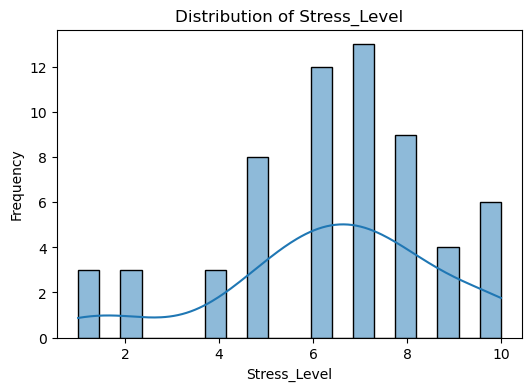

In [81]:
# Histogram + KDE
plt.figure(figsize=(6,4))
sns.histplot(df[target_col], bins=20, kde=True)
plt.title("Distribution of Stress_Level")
plt.xlabel("Stress_Level")
plt.ylabel("Frequency")
plt.show()

In [82]:
stress_skew = skew(df[target_col])
stress_kurt = kurtosis(df[target_col])

In [83]:
print("Skewness:", stress_skew)
print("Kurtosis:", stress_kurt)
print("\nSummary:\n", df[target_col].describe())

Skewness: -0.6022716813969011
Kurtosis: 0.17755553271072122

Summary:
 count    61.000000
mean      6.426230
std       2.283703
min       1.000000
25%       5.000000
50%       7.000000
75%       8.000000
max      10.000000
Name: Stress_Level, dtype: float64


In [86]:
numeric_cols = [
    "Age",
    "Work_Productivity_Score",
    "Stress_Level",
    "Caffeine_Intake_Cups"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [87]:
df = df.drop(columns=["Timestamp"])

In [88]:
print("Data Types:\n")
print(df.dtypes)

print("\nMissing Values:\n")
print(df.isnull().sum())

df.head()

Data Types:

Age                            int64
Gender                        object
Occupation                    object
Device_Type                   object
Work_Productivity_Score        int64
Weekend_Screen_Time_Hours    float64
Daily_Phone_Hours            float64
Sleep_Hours                  float64
Social_Media_Hours           float64
Stress_Level                   int64
Caffeine_Intake_Cups           int64
dtype: object

Missing Values:

Age                          0
Gender                       0
Occupation                   0
Device_Type                  0
Work_Productivity_Score      0
Weekend_Screen_Time_Hours    0
Daily_Phone_Hours            0
Sleep_Hours                  0
Social_Media_Hours           0
Stress_Level                 0
Caffeine_Intake_Cups         0
dtype: int64


,Age,Gender,Occupation,Device_Type,Work_Productivity_Score,Weekend_Screen_Time_Hours,Daily_Phone_Hours,Sleep_Hours,Social_Media_Hours,Stress_Level,Caffeine_Intake_Cups
0,22,Male,Student,iOS,6,4.0,4.0,7.0,1.5,7,3
1,23,Female,Student,iOS,9,2.5,2.0,7.0,0.5,2,0
2,23,Female,Student;Professional,iOS,6,6.0,4.0,7.5,3.0,4,3
3,23,Male,Student,iOS,6,4.5,3.0,8.0,2.0,5,1
4,24,Female,Student,iOS,10,9.0,7.0,6.5,5.0,7,0


In [89]:
df.to_csv("../data/processed/structured_responses.csv")